In [1]:
%matplotlib widget
%matplotlib inline
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [17]:
from dataclasses import dataclass

@dataclass
class Result():
    n_integrals_m : list[int]
    n_integrals_e : list[int]
    n_integrals_h : list[int]
    weight_m : list[int]
    weight_e : list[int]
    weight_h : list[int]
    avg_mae : list[float]
    std_mae : list[float]
    avg_time : list[float]
    std_time : list[float]
    avg_max_err : list[float] #average between groups, of max within groups (groups = n_energy, where each seed is a different result)
    max_max_err : list[float] #max between groups
    std_max_err : list[float]

#Import pickled data object
def reconstruct (file: str):
    with open(file, 'rb') as f:
        soliton_raw = pickle.load(f) #this is a list of the dicts of the experimental results, see above experiments for keys

    n_integrals_m = []
    n_integrals_e = []
    n_integrals_h = []
    weight_m = []
    weight_e = []
    weight_h = []
    avg_mae = []
    std_mae = []
    avg_time = []
    std_time = []
    avg_max_err = [] #average between groups, of max within groups (groups = n_energy, where each seed is a different result)
    max_max_err = [] #max between groups
    std_max_err = []
    

    #Reconstructing usable experiment data
    print("Loaded Experiment Results:\n") #formatting
    for result in soliton_raw:
        n_integrals_m.append(result['n_integrals']['momentum'])
        n_integrals_e.append(result['n_integrals']['energy'])
        n_integrals_h.append(result['n_integrals']['hamiltonian'])
        weight_m.append(result['weights']['momentum'])
        weight_e.append(result['weights']['energy'])
        weight_h.append(result['weights']['hamiltonian'])
        avg_mae.append(result['mae_mean'])
        std_mae.append(result['mae_std'])
        avg_time.append(result['time_mean'])
        std_time.append(result['time_std'])
        avg_max_err.append(np.mean(result['raw_data']['max_error']))
        max_max_err.append(np.max(result['raw_data']['max_error']))
        std_max_err.append(np.std(result['raw_data']['max_error']))
        #printing out values
        print(f" Avg MAE: {result['mae_mean']:.6e} | Avg Time: {result['time_mean']:.2e}s | Avg Max Error: {np.mean(result['raw_data']['max_error']):.6e}")
        print(f"---------------| Std MAE: {result['mae_std']:.6e} | Std Time: {result['time_std']:.2e}s | Std Max Error: {np.std(result['raw_data']['max_error']):.6e}")

    result = Result(n_integrals_m, n_integrals_e, n_integrals_h,
                    weight_m, weight_e, weight_h,
                    avg_mae, std_mae, avg_time, 
                    std_time, avg_max_err, max_max_err, std_max_err)
    return result

def dual_weights_v_err(result):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    x = result.weight_e
    y = result.weight_h
    z = result.avg_max_err
    ax.errorbar(x, y, z, zerr=result.std_max_err, fmt='o', ecolor='red')
    ax.set_xlabel('Energy Weight')
    ax.set_ylabel('Hamiltonian Weight')
    ax.set_zlabel('\nMax Error', rotation=90, linespacing=1.0) 
    ax.set_box_aspect(None, zoom=0.80)
    return fig


In [18]:
result = reconstruct('2_soliton_energy_hamilt_weight_test.pkl')

Loaded Experiment Results:

 Avg MAE: 2.803688e-03 | Avg Time: 1.39e+03s | Avg Max Error: 7.900405e-02
---------------| Std MAE: 1.102007e-03 | Std Time: 9.49e+01s | Std Max Error: 7.368907e-02
 Avg MAE: 8.814147e-03 | Avg Time: 3.38e+03s | Avg Max Error: 1.999451e-01
---------------| Std MAE: 7.013700e-04 | Std Time: 8.91e+02s | Std Max Error: 5.995510e-03
 Avg MAE: 1.121482e-02 | Avg Time: 4.44e+03s | Avg Max Error: 2.307127e-01
---------------| Std MAE: 1.959189e-03 | Std Time: 4.17e+02s | Std Max Error: 7.239389e-02
 Avg MAE: 1.091077e-02 | Avg Time: 5.01e+03s | Avg Max Error: 2.527638e-01
---------------| Std MAE: 1.185985e-03 | Std Time: 1.05e+03s | Std Max Error: 4.036577e-02
 Avg MAE: 1.420832e-02 | Avg Time: 6.43e+03s | Avg Max Error: 3.214524e-01
---------------| Std MAE: 2.157761e-03 | Std Time: 1.74e+03s | Std Max Error: 6.499935e-02
 Avg MAE: 2.076514e-02 | Avg Time: 6.39e+03s | Avg Max Error: 4.002984e-01
---------------| Std MAE: 3.848479e-03 | Std Time: 1.44e+03s | Std 

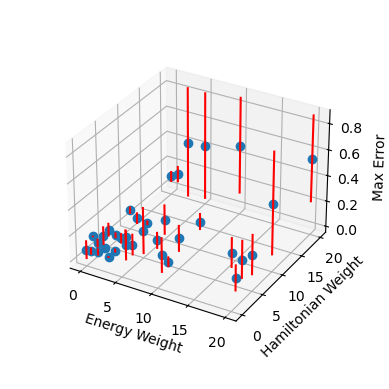

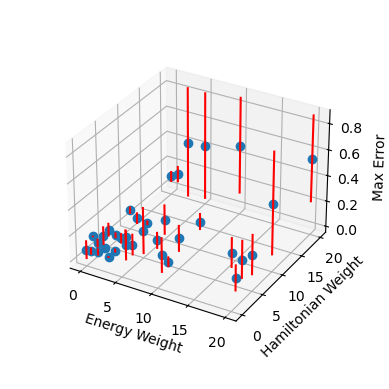

In [19]:
dual_weights_v_err(result)

In [7]:
np.argmin(result.avg_mae)

np.int64(13)

In [8]:
np.argmin(result.avg_max_err)

np.int64(13)

In [9]:
np.argmin(result.std_mae)

np.int64(13)

In [10]:
np.argmin(result.max_max_err)

np.int64(13)

In [12]:
print(f'Result: 13 | MAE: {result.avg_mae[13]} | AME: {result.avg_max_err[13]} | MME: {result.max_max_err[13]}')
print(f'---------- | STD of MAE: {result.std_mae[13]} | STD of ME {result.std_max_err[13]}')

Result: 13 | MAE: 0.0025089341991891465 | AME: 0.03281156594554583 | MME: 0.03402295336127281
---------- | STD of MAE: 0.00039079425695295915 | STD of ME 0.0008792766038046007


In [13]:
print(f'Result: 0 | MAE: {result.avg_mae[0]} | AME: {result.avg_max_err[0]} | MME: {result.max_max_err[0]}')
print(f'---------- | STD of MAE: {result.std_mae[0]} | STD of ME {result.std_max_err[0]}')

Result: 0 | MAE: 0.0028036884032189846 | AME: 0.07900404557585716 | MME: 0.18321597576141357
---------- | STD of MAE: 0.0011020072254374644 | STD of ME 0.07368907361113655


In [15]:
print(f'Energy: {result.weight_e[13]} | Hamiltonian: {result.weight_h[13]}')

Energy: 1.0 | Hamiltonian: 2.5
